# 원하는 포즈로 이미지 만드는 도구 (OpenPose + ControlNet)

사진 한 장에서 사람의 **자세(관절)만** 뽑아내고, 그 자세를 유지한 채 **완전히 다른 인물·장면**을 만드는 도구입니다.

```
참조 사진  →  OpenPose 스켈레톤  →  ControlNet  →  결과 이미지
           (자세만 남고 얼굴·옷·배경은 버려짐)   (내용은 프롬프트로 새로 지정)
```

**처음 보는 사람은 위에서 아래로 셀을 순서대로 실행하면 됩니다.** 각 셀 첫 줄 주석에 그 셀이 하는 일이 적혀 있습니다.

| 항목 | 값 |
|---|---|
| 실행 환경 | Google Colab · 무료 T4 GPU |
| 기본 모델 | Stable Diffusion 1.5 (`PRESET = "sd15"`) |
| 포즈 조건 | `lllyasviel/control_v11p_sd15_openpose` (ControlNet 1.1) |
| 예상 소요 | 설치·다운로드 5–8분 + 이미지 1장당 3–5초 |

---

### 왜 FLUX.2-klein-4B를 쓰지 않았나

이 노트는 강의에서 쓴 FLUX.2-klein-4B(GGUF Q4) 데모에서 출발했습니다. 조사해 본 결과 FLUX.2-klein **9B**용 포즈 제어는 커뮤니티에 존재하지만(Civitai의 depth/openpose 워크플로, `refcontrol` 포즈 LoRA 등), 전부 9B 기준이고 ComfyUI 커스텀 노드를 전제로 합니다. 무료 T4 16GB에서 4B Q4도 이미지 1장에 33초가 걸렸던 만큼 9B + ControlNet은 실행이 어렵습니다.

그래서 **같은 목적을 달성할 수 있는 SD1.5 + OpenPose ControlNet**으로 대체했습니다. 과제가 허용한 "비슷한 모델" 범위입니다. 자세한 내용은 마지막 `한계` 절에 정리했습니다.

## 0. GPU 확인

GPU가 붙어 있는지 먼저 봅니다. 안 붙어 있으면 상단 메뉴 **런타임 → 런타임 유형 변경 → T4 GPU** 로 바꾸고 다시 실행하세요.

In [2]:
# 이 셀이 하는 일: GPU가 할당됐는지 확인합니다. Tesla T4 / 15360 MiB 정도가 보이면 정상입니다.
!nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv

name, memory.total [MiB], memory.used [MiB]
Tesla T4, 15360 MiB, 0 MiB


## 1. 라이브러리 설치

두 개만 있으면 됩니다.

- `diffusers` — 이미지 생성 파이프라인
- `controlnet_aux` — 사진에서 사람 관절(OpenPose)을 뽑는 전처리기

설치 후 `pip`가 의존성 충돌 경고를 뱉을 수 있는데, 우리가 쓰는 기능과는 무관하므로 무시해도 됩니다. **"런타임을 다시 시작하라"는 안내가 떠도 무시하고 다음 셀로 넘어가세요.**

In [3]:
# 이 셀이 하는 일: 필요한 라이브러리를 설치합니다. (2–3분, GPU는 쓰지 않음)
!pip install -q -U diffusers transformers accelerate safetensors
!pip install -q controlnet_aux
print("설치 완료")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 9.1 MB/s eta 0:00:00
설치 완료


## 2. 설정 — 고정할 값을 한 곳에 모으기

실험에서 **고정해야 하는 값**을 전부 이 셀에 몰아넣습니다. 이렇게 해두면 "어떤 조건으로 만든 이미지였는지"를 나중에 추적할 수 있고, 조건을 바꿀 때도 여기 한 곳만 고치면 됩니다.

**시드는 난수로 뽑지 않고 문자열에서 계산합니다.** 파이썬 내장 `hash()`는 실행할 때마다 값이 달라져서 재현이 깨지므로 쓰지 않고, `hashlib.sha256`을 씁니다. 덕분에 런타임을 새로 켜도, 다른 사람이 이 노트를 돌려도 같은 시드가 나옵니다.

- `PRESET` — `"sd15"`(빠름, 권장) / `"sdxl"`(느리지만 고화질)
- `CONTROL_SCALE` — 포즈를 얼마나 강하게 따를지. 낮으면 느슨하게, 높으면 강하게

In [4]:
# 이 셀이 하는 일: 모델·해상도·스텝·시드 규칙을 고정합니다. 조건을 바꾸려면 여기만 고칩니다.
import os, glob, json, hashlib, torch

PRESET = "sd15"          # "sd15" 또는 "sdxl"

PRESETS = {
    "sd15": {
        # 주의: 인터넷 예제에 많이 나오는 "runwayml/stable-diffusion-v1-5" 는
        #      2024년 8월에 삭제되어 404가 납니다. 아래가 현재 유효한 저장소입니다.
        "base": "stable-diffusion-v1-5/stable-diffusion-v1-5",
        "cnet": "lllyasviel/control_v11p_sd15_openpose",   # ControlNet 1.1
        "size": (512, 512),
        "steps": 20,
        "guidance": 7.5,
    },
    "sdxl": {
        "base": "stabilityai/stable-diffusion-xl-base-1.0",
        "cnet": "thibaud/controlnet-openpose-sdxl-1.0",
        "size": (1024, 1024),
        "steps": 25,
        "guidance": 7.0,
    },
}
CFG = PRESETS[PRESET]

CONTROL_SCALE = 1.0      # 포즈 추종 강도 (0.5 느슨함 ~ 1.5 강함)
NEGATIVE = "lowres, bad anatomy, extra limbs, deformed hands, watermark, text, blurry"

POSE_DIR, OUT_DIR = "/content/poses", "/content/out"
os.makedirs(POSE_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32


def make_seed(tag):
    """문자열 tag를 항상 같은 숫자 시드로 바꿉니다.
    내장 hash()는 실행마다 값이 달라지므로 sha256을 사용합니다."""
    return int(hashlib.sha256(tag.encode("utf-8")).hexdigest()[:16], 16) % (2 ** 32)


# 실제로 설치된 버전을 기록해 둡니다 (재현할 때 필요한 정보)
import diffusers, transformers
VERSIONS = {"torch": torch.__version__,
            "diffusers": diffusers.__version__,
            "transformers": transformers.__version__}

print("프리셋:", PRESET, "|", CFG["base"])
print("장치:", DEVICE, DTYPE)
print("버전:", VERSIONS)
print("시드 규칙 확인 — 'pose01|astronaut|1.0' →", make_seed("pose01|astronaut|1.0"))

프리셋: sd15 | stable-diffusion-v1-5/stable-diffusion-v1-5
장치: cuda torch.float16
버전: {'torch': '2.11.0+cu128', 'diffusers': '0.39.0', 'transformers': '5.14.1'}
시드 규칙 확인 — 'pose01|astronaut|1.0' → 340336256


## 3. 모델 로드 (한 번만)

모델을 GPU에 **한 번만** 올리고 이후 모든 생성에서 재사용합니다. 이미지마다 다시 올리면 매번 몇 분씩 낭비됩니다.

처음 실행할 때 약 3.4GB를 내려받으므로 3–5분 걸립니다. 두 번째부터는 캐시에서 바로 읽습니다.

> 인터넷 예제 상당수가 `OpenposeDetector.from_pretrained('lllyasviel/ControlNet')` 을 쓰지만, 전처리기 가중치는 `lllyasviel/Annotators` 로 옮겨졌습니다.

In [5]:
# 이 셀이 하는 일: 포즈 추출기와 생성 파이프라인을 한 번만 메모리에 올립니다.
from diffusers import (ControlNetModel, StableDiffusionControlNetPipeline,
                       StableDiffusionXLControlNetPipeline, UniPCMultistepScheduler)
from controlnet_aux import OpenposeDetector

# 포즈 추출기 — CPU에서 동작하므로 GPU를 쓰지 않습니다.
pose_detector = OpenposeDetector.from_pretrained("lllyasviel/Annotators")

# 포즈 조건을 받아들이는 ControlNet
controlnet = ControlNetModel.from_pretrained(CFG["cnet"], torch_dtype=DTYPE)

# 생성 파이프라인
PipeCls = StableDiffusionXLControlNetPipeline if PRESET == "sdxl" else StableDiffusionControlNetPipeline
kwargs = dict(controlnet=controlnet, torch_dtype=DTYPE)
if PRESET == "sd15":
    kwargs.update(safety_checker=None, requires_safety_checker=False)
pipe = PipeCls.from_pretrained(CFG["base"], **kwargs)

if PRESET == "sdxl":
    # SDXL 기본 VAE는 float16에서 검은 이미지가 나오는 알려진 문제가 있어 수정판으로 교체합니다.
    from diffusers import AutoencoderKL
    pipe.vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=DTYPE)

pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing()          # VRAM 절약
pipe.set_progress_bar_config(disable=True)
print("모델 준비 완료")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via

body_pose_model.pth: reconstructing file:   0%|          |  0.00B /  209MB            

body_pose_model.pth: downloading bytes:           |  0.00B            

hand_pose_model.pth: reconstructing file:   0%|          |  0.00B /  147MB            

hand_pose_model.pth: downloading bytes:           |  0.00B            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

모델 준비 완료


## 4. 참조 사진 넣기

자세를 가져올 사진을 올립니다. **팔다리가 모두 보이는 전신 사진**이어야 관절이 잡힙니다. 얼굴 클로즈업이나 상반신만 있는 사진은 실패합니다.

파일 2장을 한 번에 선택하면 **파일명 알파벳 순**으로 `pose01`, `pose02` 가 됩니다. 순서를 확실히 하고 싶으면 미리 파일명을 `a_....jpg`, `b_....jpg` 로 바꿔두세요.

> **저작권**: 결과물을 공개 저장소에 올릴 예정이므로 본인이 찍은 사진이나 자유 이용이 허용된 사진(Pexels, Unsplash 등)을 쓰세요.

In [6]:
# 이 셀이 하는 일: 참조 사진을 업로드해 /content/poses 에 pose01, pose02 로 저장합니다.
import shutil
from google.colab import files

uploaded = files.upload()
for i, name in enumerate(sorted(uploaded.keys())[:2], start=1):
    ext = os.path.splitext(name)[1].lower() or ".jpg"
    dst = f"{POSE_DIR}/pose{i:02d}{ext}"
    shutil.move(name, dst)
    print(f"{name}  →  {dst}")

print("현재 참조 사진:", sorted(glob.glob(POSE_DIR + "/*")))

Saving pexels-marcus-aurelius-6787355.jpg to pexels-marcus-aurelius-6787355.jpg
Saving pexels-marta-wave-6453400.jpg to pexels-marta-wave-6453400.jpg
pexels-marcus-aurelius-6787355.jpg  →  /content/poses/pose01.jpg
pexels-marta-wave-6453400.jpg  →  /content/poses/pose02.jpg
현재 참조 사진: ['/content/poses/pose01.jpg', '/content/poses/pose02.jpg']


## 5. 포즈 추출 — 사진에서 관절만 뽑기

OpenPose가 사진에서 관절 위치를 찾아 **검은 배경에 색선으로 된 스켈레톤 이미지**를 만듭니다. ControlNet에 실제로 들어가는 조건은 이 스켈레톤이고, 원본 사진의 얼굴·옷·배경은 전달되지 않습니다.

관절이 하나도 안 잡힌 사진은 **건너뛰고** 어느 사진이 실패했는지 알려줍니다. 검출에 실패한 사진을 그대로 넣으면 스켈레톤이 전부 검정이 되어, 포즈가 반영되지 않은 이미지가 "성공"으로 기록되는 조용한 오염이 생깁니다. 그래서 미리 걸러냅니다.

[pose01] 관절 추출 성공
[pose02] 관절 추출 성공
실패한 사진: 없음
pose01


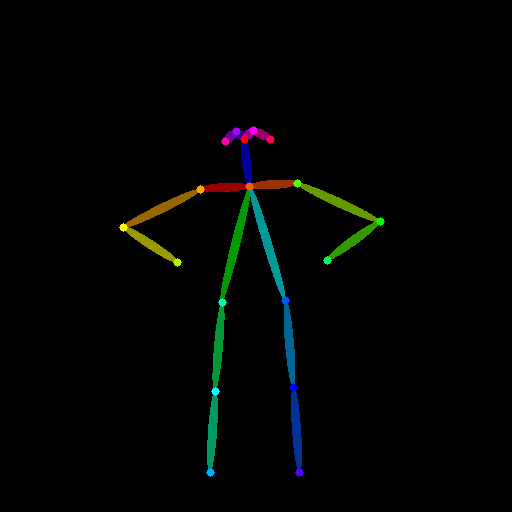

pose02


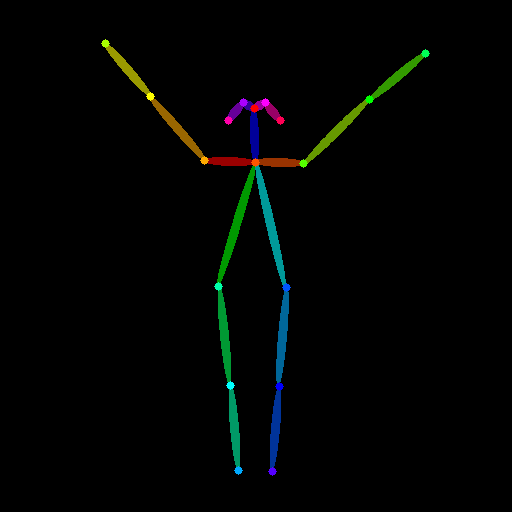

In [11]:
# 이 셀이 하는 일: 참조 사진마다 관절을 뽑아 스켈레톤을 만듭니다.
#                검출 실패한 사진은 건너뛰고 마지막에 실패 목록을 출력합니다.
import numpy as np
from PIL import Image


def extract_pose(path, size):
    img = Image.open(path).convert("RGB").resize(size, Image.LANCZOS)
    skeleton = pose_detector(img).resize(size, Image.LANCZOS)
    if np.array(skeleton).max() == 0:          # 전부 검정 = 관절을 못 찾음
        raise ValueError("관절 검출 실패 (전신이 보이는 사진이 필요합니다)")
    return img, skeleton


POSES, pose_failed = {}, []
for path in sorted(glob.glob(POSE_DIR + "/*")):
    pid = os.path.splitext(os.path.basename(path))[0]
    try:
        POSES[pid] = extract_pose(path, CFG["size"])
        POSES[pid][1].save(f"{OUT_DIR}/{pid}_skeleton.png")
        print(f"[{pid}] 관절 추출 성공")
    except Exception as e:
        pose_failed.append((pid, str(e)))
        print(f"[{pid}] 건너뜀 — {e}")

print("실패한 사진:", pose_failed if pose_failed else "없음")
for pid in POSES:
    print(pid)
    display(POSES[pid][1])

## 6. 생성 함수 — 이미지 + 재현 정보 + 비교 그림

`run()` 한 번이 세 가지를 남깁니다.

1. `out/{이름}.png` — 결과 이미지
2. `out/{이름}.json` — **프롬프트 · 시드 · 시드 규칙 · 모델 · 스텝 · 강도 · 라이브러리 버전**  
   이 파일만 있으면 같은 이미지를 다시 만들 수 있습니다.
3. `out/{이름}_compare.png` — `참조 사진 | 스켈레톤 | 결과` 를 나란히 붙인 비교 그림  
   포즈가 실제로 반영됐는지 눈으로 확인하는 용도입니다.

In [17]:
# 이 셀이 하는 일: (포즈, 프롬프트) 한 쌍으로 이미지를 만들고 결과·메타데이터·비교그림을 저장합니다.
from PIL import ImageDraw


def _label(img, text):
    """이미지 위에 흰 띠를 붙이고 설명을 적습니다."""
    out = Image.new("RGB", (img.width, img.height + 24), "white")
    out.paste(img, (0, 24))
    ImageDraw.Draw(out).text((6, 7), text, fill="black")
    return out


def run(pose_id, prompt_id, prompt, scale=None):
    if pose_id not in POSES:
        raise ValueError(f"{pose_id} 포즈가 없습니다 (업로드 안 됐거나 관절 추출 실패)")
    scale = CONTROL_SCALE if scale is None else scale
    ref, skeleton = POSES[pose_id]

    # 시드는 조건 문자열에서 계산 → 같은 조건이면 항상 같은 이미지
    tag = f"{pose_id}|{prompt_id}|{scale}"
    seed = make_seed(tag)
    generator = torch.Generator(device=DEVICE).manual_seed(seed)

    image = pipe(prompt=prompt, negative_prompt=NEGATIVE, image=skeleton,
                 num_inference_steps=CFG["steps"], guidance_scale=CFG["guidance"],
                 controlnet_conditioning_scale=scale, generator=generator,
                 width=CFG["size"][0], height=CFG["size"][1]).images[0]

    name = f"{pose_id}_{prompt_id}"
    image.save(f"{OUT_DIR}/{name}.png")

    # 참조 | 스켈레톤 | 결과 비교 그림
    w, h = ref.width, ref.height + 24
    panel = Image.new("RGB", (w * 3, h), "white")
    for i, (im, text) in enumerate([(ref, "1. reference photo"),
                                    (skeleton, "2. openpose skeleton"),
                                    (image, "3. generated")]):
        panel.paste(_label(im, text), (i * w, 0))
    panel.save(f"{OUT_DIR}/{name}_compare.png")

    # 재현에 필요한 정보 기록
    meta = {"name": name, "pose": pose_id, "prompt_id": prompt_id,
            "prompt": prompt, "negative_prompt": NEGATIVE,
            "seed": seed, "seed_tag": tag,
            "seed_rule": "int(sha256(seed_tag)[:16], 16) % 2**32",
            "base_model": CFG["base"], "controlnet": CFG["cnet"],
            "steps": CFG["steps"], "guidance": CFG["guidance"],
            "control_scale": scale, "size": list(CFG["size"]),
            "versions": VERSIONS}
    with open(f"{OUT_DIR}/{name}.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    print(f"[{name}] seed={seed} scale={scale}")
    return panel

## 7. 먼저 한 장

도구가 도는지 확인합니다. SD1.5 기준 5초 내외입니다.

**볼 것:** 가운데 스켈레톤의 팔다리 방향과 오른쪽 결과의 팔다리 방향이 같은가.

[pose01_astronaut] seed=340336256 scale=1.0


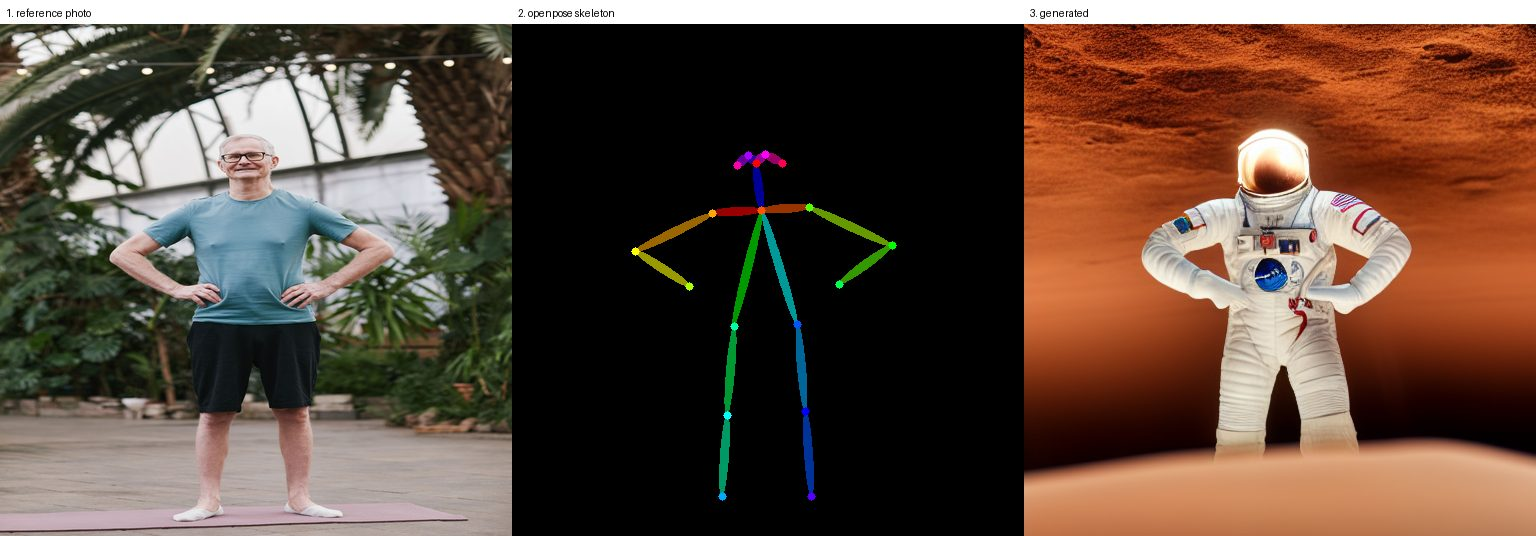

In [18]:
# 이 셀이 하는 일: 첫 이미지 한 장을 만들어 비교 그림으로 보여줍니다.
display(run("pose01", "astronaut",
            "an astronaut in a white spacesuit, on the surface of mars, cinematic lighting, highly detailed"))

## 8. 조건 바꿔보기 — 무엇을 바꾸면 결과가 크게 달라지나

두 방향으로 나눠 봅니다.

- **같은 포즈 + 다른 프롬프트** → 자세는 유지되고 내용만 바뀌어야 정상
- **같은 프롬프트 + 다른 포즈** → 내용은 유지되고 자세만 바뀌어야 정상

한 조합이 실패해도 나머지는 계속 진행하고, 마지막에 실패 목록을 출력합니다.

[pose01_astronaut] seed=340336256 scale=1.0


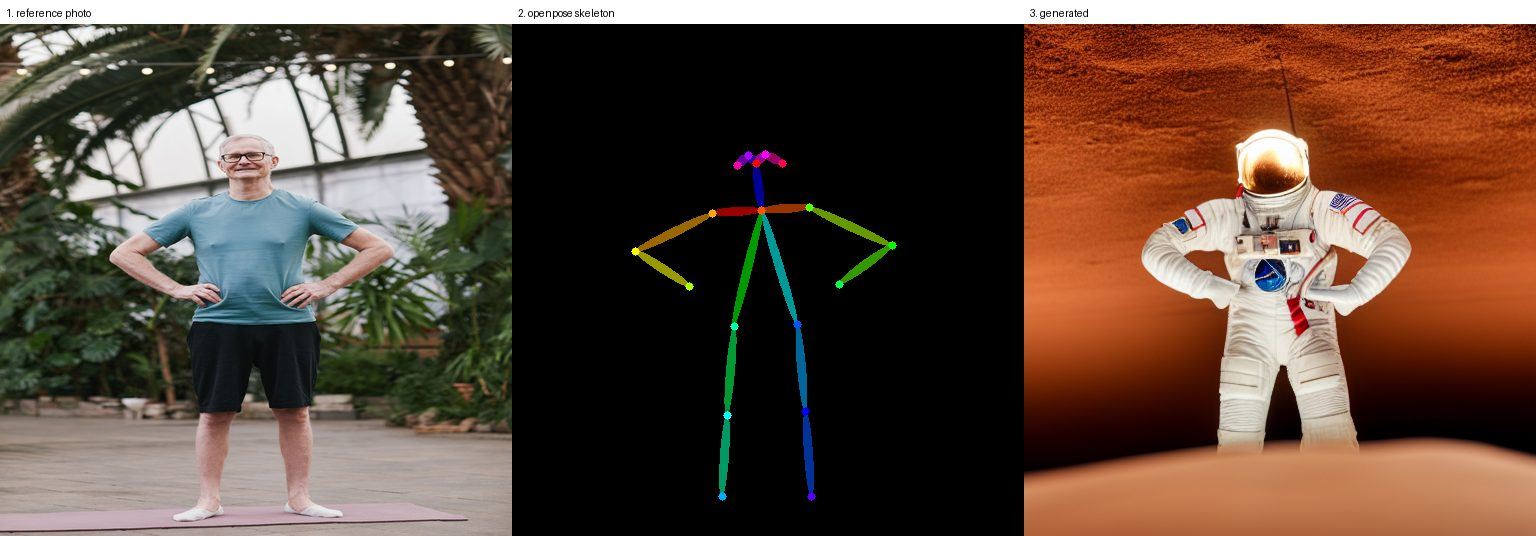

[pose01_knight] seed=3308244251 scale=1.0


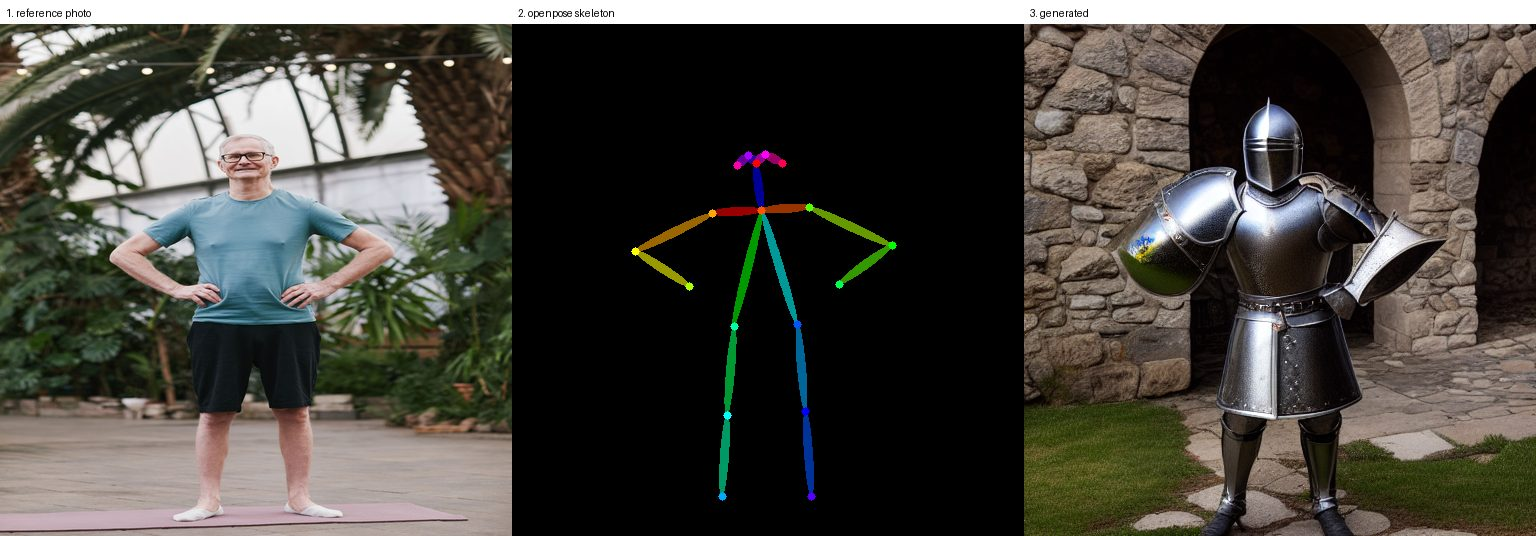

[pose01_watercolor] seed=3378889150 scale=1.0


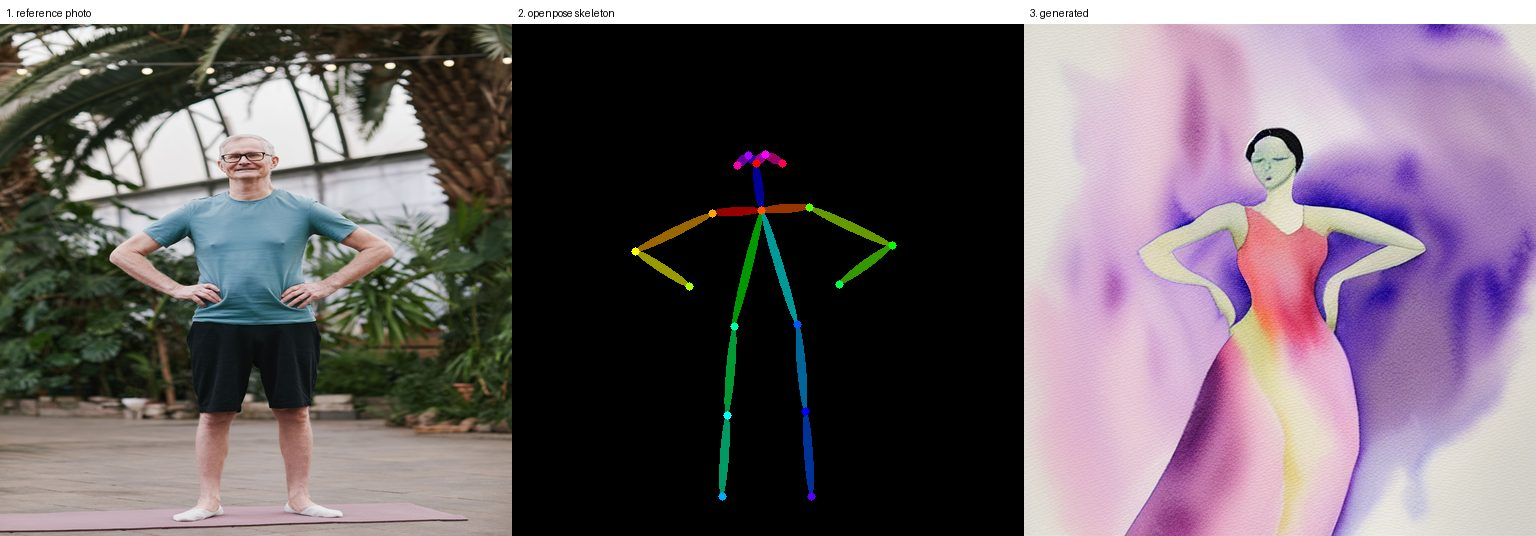

[pose02_astronaut] seed=1711213817 scale=1.0


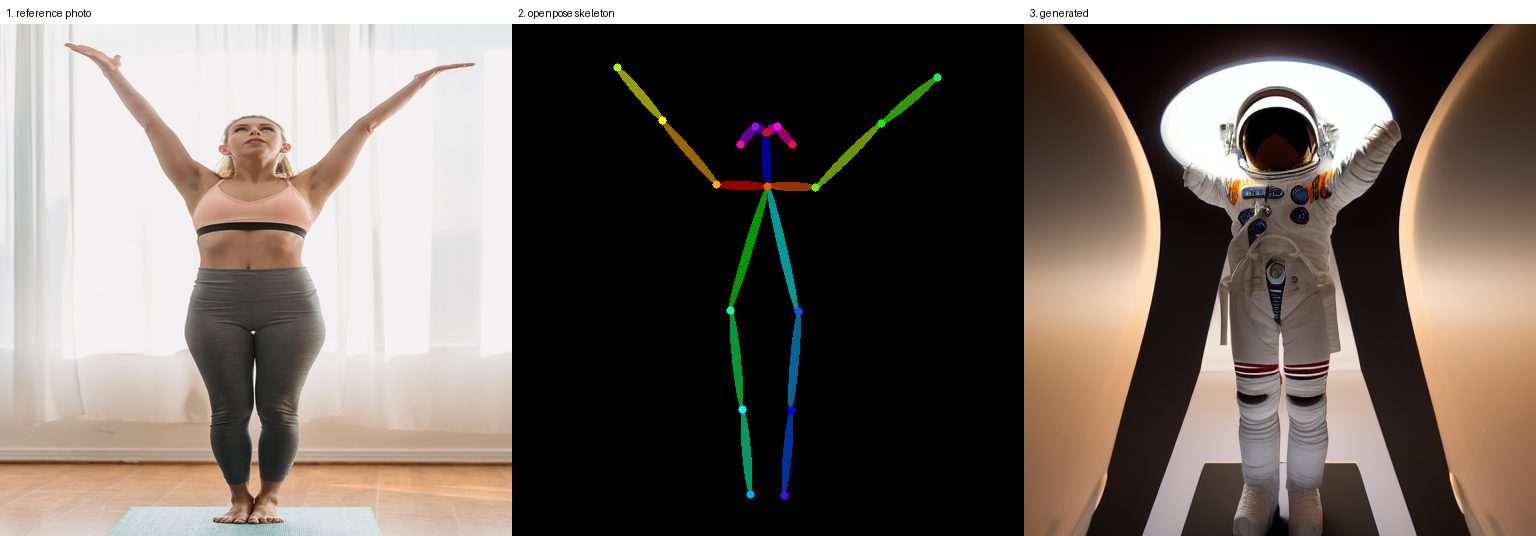

[pose02_knight] seed=3528176645 scale=1.0


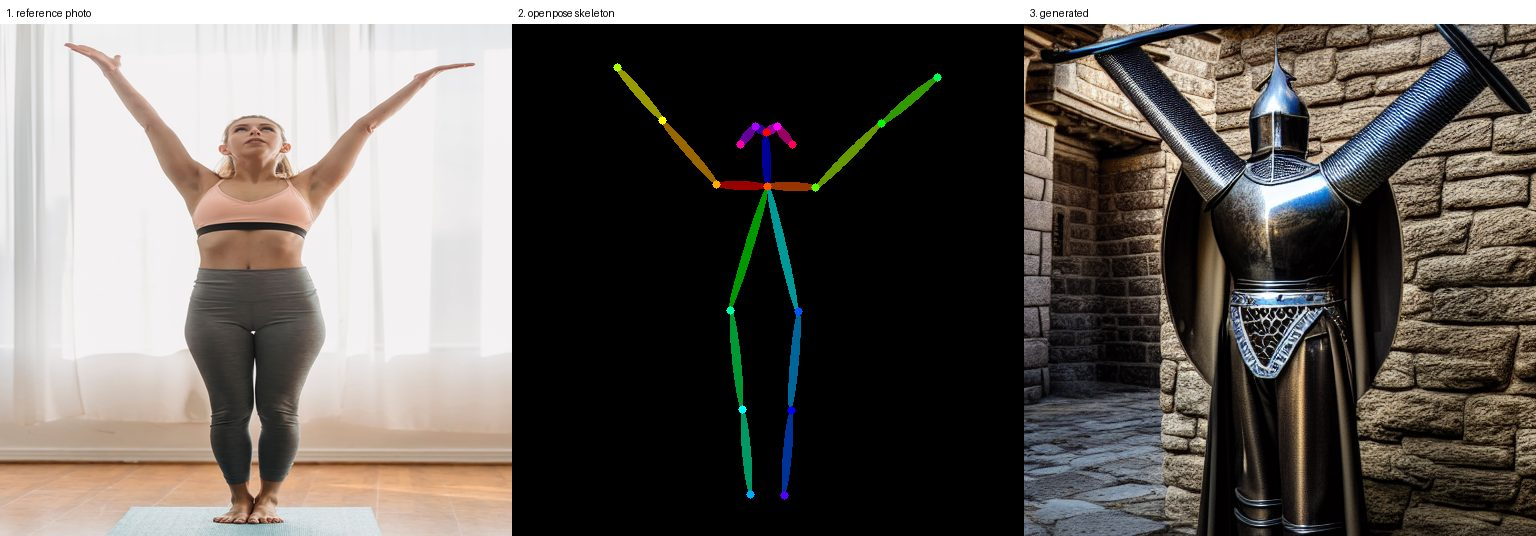

실패한 조합: 없음


In [19]:
# 이 셀이 하는 일: 포즈와 프롬프트를 교차해 여러 장 만듭니다. (SD1.5 기준 전체 30초 내외)
TESTS = [
    # 같은 포즈(pose01)에 프롬프트만 바꿈
    ("pose01", "astronaut",  "an astronaut in a white spacesuit, on the surface of mars, cinematic lighting"),
    ("pose01", "knight",     "a medieval knight in polished steel armor, stone castle courtyard, dramatic light"),
    ("pose01", "watercolor", "watercolor painting of a dancer, soft pastel colors, visible paper texture"),
    # 같은 프롬프트에 포즈만 바꿈 (pose02)
    ("pose02", "astronaut",  "an astronaut in a white spacesuit, on the surface of mars, cinematic lighting"),
    ("pose02", "knight",     "a medieval knight in polished steel armor, stone castle courtyard, dramatic light"),
]

failed = []
for pose_id, prompt_id, prompt in TESTS:
    try:
        display(run(pose_id, prompt_id, prompt))
    except Exception as e:
        failed.append((f"{pose_id}_{prompt_id}", str(e)))
        print(f"건너뜀: {pose_id}_{prompt_id} — {e}")

print("실패한 조합:", failed if failed else "없음")

## 9. 포즈 추종 강도 비교

`controlnet_conditioning_scale` 을 바꿔가며 **포즈를 얼마나 강하게 따르는지** 봅니다.

- 낮으면(0.5) 그림은 자연스러워지지만 자세가 흐트러집니다
- 높으면(1.5) 자세는 정확해지지만 인물이 뻣뻣해지거나 형태가 무너집니다

루브릭의 "입력 이미지의 포즈가 정말 그대로 반영됐는가"에 직접 답하는 실험입니다.

[pose01_astronaut_cs0.5] seed=4133274400 scale=0.5


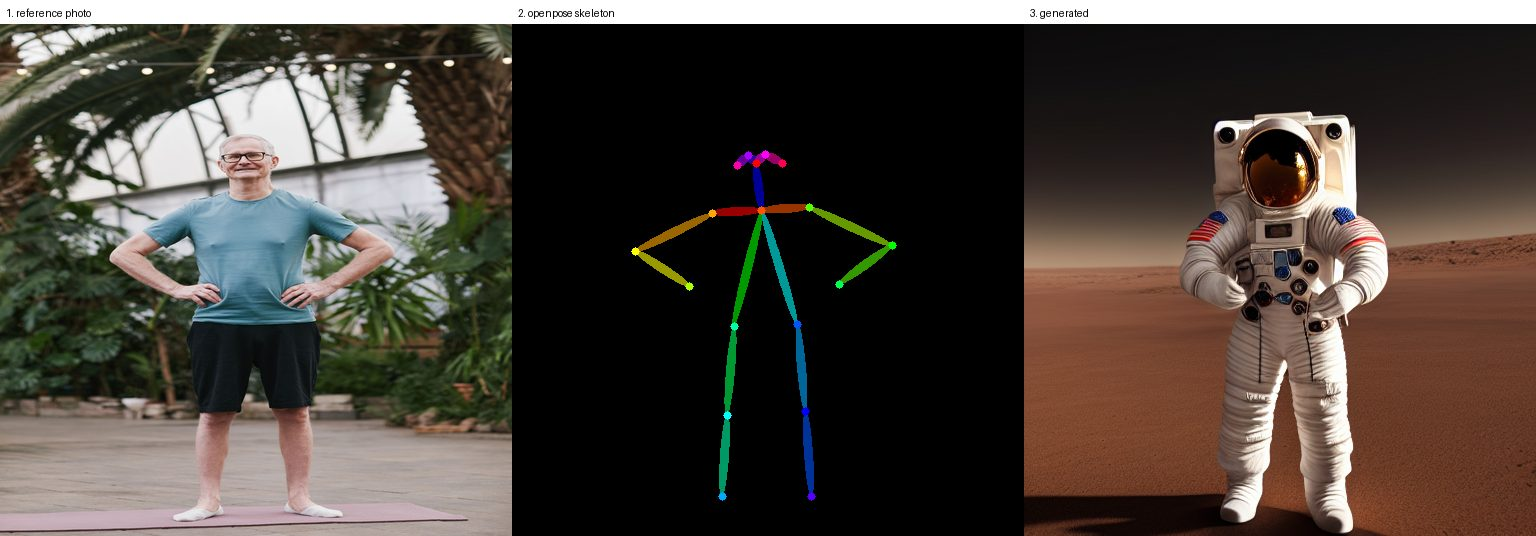

[pose01_astronaut_cs1.0] seed=914889995 scale=1.0


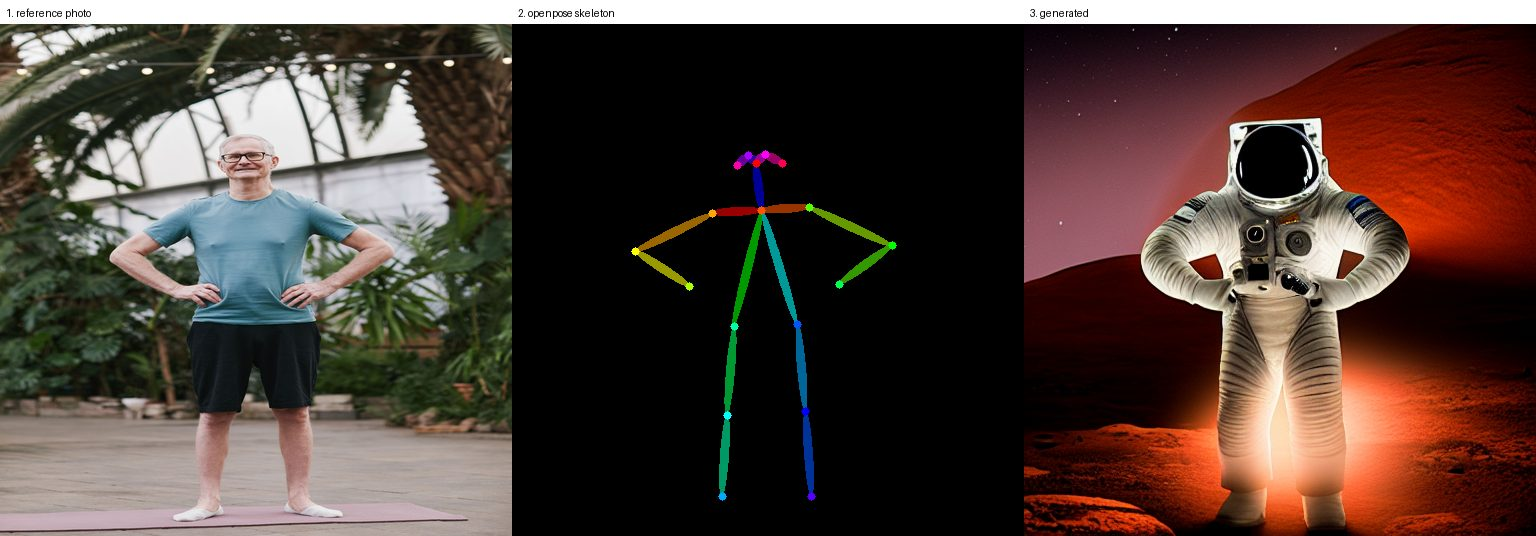

[pose01_astronaut_cs1.5] seed=963086047 scale=1.5


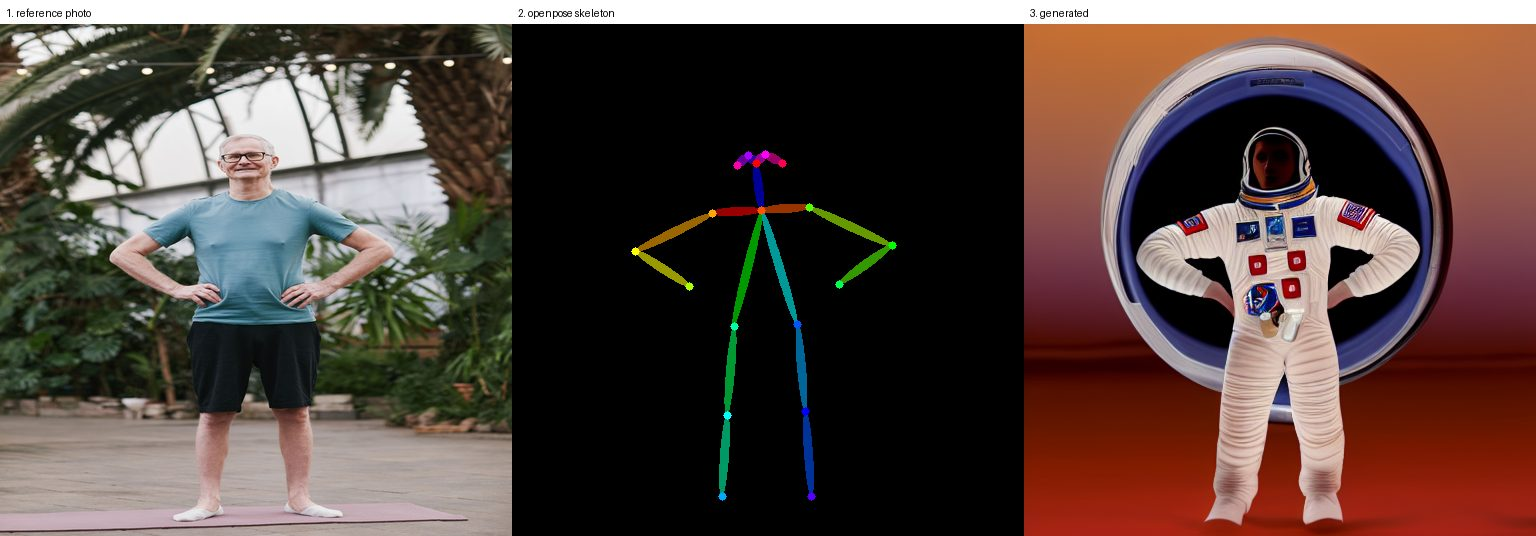

In [20]:
# 이 셀이 하는 일: 같은 포즈·같은 프롬프트에서 포즈 추종 강도만 0.5 / 1.0 / 1.5 로 바꿔 비교합니다.
for s in [0.5, 1.0, 1.5]:
    try:
        display(run("pose01", f"astronaut_cs{s}",
                    "an astronaut in a white spacesuit, on the surface of mars, cinematic lighting",
                    scale=s))
    except Exception as e:
        print(f"건너뜀: scale={s} — {e}")

## 10. 재현 확인

같은 조건이면 **언제 다시 돌려도 같은 시드**가 나와야 합니다. 저장된 json의 시드와, 규칙으로 다시 계산한 시드를 비교합니다. 전부 `일치` 여야 정상입니다.

시드가 문자열에서 계산되기 때문에 런타임을 새로 켜거나 다른 사람이 이 노트를 돌려도 같은 값이 나옵니다.

In [21]:
# 이 셀이 하는 일: 저장된 json의 시드를 규칙으로 다시 계산해 재현성을 검증합니다.
mismatch = []
for path in sorted(glob.glob(OUT_DIR + "/*.json")):
    m = json.load(open(path, encoding="utf-8"))
    recomputed = make_seed(m["seed_tag"])
    ok = recomputed == m["seed"]
    if not ok:
        mismatch.append(m["name"])
    print(f"{m['name']:24s} {m['seed']:>12}  {'일치' if ok else '불일치'}")

print("\n불일치:", mismatch if mismatch else "없음 — 재현성 확인됨")

pose01_astronaut            340336256  일치
pose01_astronaut_cs0.5     4133274400  일치
pose01_astronaut_cs1.0      914889995  일치
pose01_astronaut_cs1.5      963086047  일치
pose01_knight              3308244251  일치
pose01_watercolor          3378889150  일치
pose02_astronaut           1711213817  일치
pose02_knight              3528176645  일치

불일치: 없음 — 재현성 확인됨


## 11. 결과 저장 및 내려받기

결과 전체를 zip으로 묶어 내려받습니다. **Colab 런타임이 끊기면 `/content` 는 전부 사라지므로 이 셀을 반드시 실행하세요.**

In [23]:
# 이 셀이 하는 일: 결과 파일 목록을 확인하고 zip으로 묶어 내려받습니다.
!ls -l --time-style=+%H:%M:%S /content/out/
!zip -qr /content/pose_results.zip /content/out /content/poses
from google.colab import files as _files
_files.download("/content/pose_results.zip")

total 9388
-rw-r--r-- 1 root root 798477 02:32:04 pose01_astronaut_compare.png
-rw-r--r-- 1 root root 762647 02:33:18 pose01_astronaut_cs0.5_compare.png
-rw-r--r-- 1 root root    724 02:33:18 pose01_astronaut_cs0.5.json
-rw-r--r-- 1 root root 343634 02:33:18 pose01_astronaut_cs0.5.png
-rw-r--r-- 1 root root 817879 02:33:25 pose01_astronaut_cs1.0_compare.png
-rw-r--r-- 1 root root    723 02:33:25 pose01_astronaut_cs1.0.json
-rw-r--r-- 1 root root 400885 02:33:25 pose01_astronaut_cs1.0.png
-rw-r--r-- 1 root root 706217 02:33:32 pose01_astronaut_cs1.5_compare.png
-rw-r--r-- 1 root root    723 02:33:32 pose01_astronaut_cs1.5.json
-rw-r--r-- 1 root root 291977 02:33:32 pose01_astronaut_cs1.5.png
-rw-r--r-- 1 root root    705 02:32:04 pose01_astronaut.json
-rw-r--r-- 1 root root 382981 02:32:04 pose01_astronaut.png
-rw-r--r-- 1 root root 938486 02:32:12 pose01_knight_compare.png
-rw-r--r-- 1 root root    701 02:32:12 pose01_knight.json
-rw-r--r-- 1 root root 522151 02:32:12 pose01_knight.png

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. 포즈 일치도 정량 측정

앞의 비교 그림은 "눈으로 봐서 같다"까지다. 여기서는 **생성된 이미지에 OpenPose를 다시 걸어** 참조 사진의 관절 좌표와 얼마나 떨어졌는지 픽셀로 재서, 포즈 반영 여부를 숫자로 판정한다.

```
참조 사진 --OpenPose--> 관절 A
생성 이미지 --OpenPose--> 관절 B     →  A와 B의 평균 거리(px)
```

이 절은 **앞 셀을 실행하지 않아도 단독으로 돌아간다.** 측정 대상 이미지를 GitHub 저장소에서 직접 받아오고, 포즈 추출기는 CPU에서 동작하므로 **GPU가 필요 없다.** 런타임 유형을 CPU로 두어도 된다.

### 왜 위치와 크기를 먼저 맞추는가

절대 픽셀 거리만 재면 **자세가 똑같아도** 인물이 조금 작게 그려지거나 옆으로 밀리면 모든 관절이 통째로 이동해 오차가 커진다. 그건 자세가 틀린 것이 아니라 구도가 다른 것이다.

그래서 목을 원점으로, 목~엉덩이중심 거리를 1로 맞춘 뒤 남은 차이만 센다. 이렇게 하면 인물 크기·위치와 무관하게 **자세 모양**만 비교된다. 비교하는 관절 집합도 양쪽 다 검출된 것으로 통일해야 행끼리 비교가 성립한다.

In [ ]:
# 이 셀이 하는 일: 포즈 추출기만 준비합니다. (생성 모델은 불필요 — GPU를 쓰지 않습니다)
#               이 절만 단독 실행할 경우를 위해 설치와 로드를 여기서 다시 합니다.
try:
    pose_detector
    print("이미 로드된 포즈 추출기를 재사용합니다")
except NameError:
    !pip install -q controlnet_aux
    from controlnet_aux import OpenposeDetector
    pose_detector = OpenposeDetector.from_pretrained("lllyasviel/Annotators")
    print("포즈 추출기 준비 완료")

In [7]:
# 이 셀이 하는 일: 자세 모양만 비교합니다.
#   1) 목을 원점으로, 목~엉덩이중심 거리를 1로 맞춰 화면 내 위치·크기 차이를 제거
#   2) 남은 차이(자세 모양)를 몸통 길이 대비 %로 계산
#   3) PCK@0.2 = 관절 중 몇 %가 몸통 길이의 20% 안에 들어왔는지
# 절대 픽셀 거리만 재면 인물이 조금 작게/옆으로 그려진 것까지 오차로 잡히므로 이렇게 정규화한다.
import io as _io, math, urllib.request
import numpy as np
from PIL import Image

RAW = "https://raw.githubusercontent.com/nike1137-svg/pose-image-tool/main/samples"
SIZE = (512, 512)

# OpenPose COCO-18 관절 이름. 14번 이후(눈·귀)는 신뢰도가 낮아 제외한다.
NAMES = ["nose", "neck", "Rsho", "Relb", "Rwri", "Lsho", "Lelb", "Lwri",
         "Rhip", "Rkne", "Rank", "Lhip", "Lkne", "Lank"]
CORE = list(range(14))

CASES = [
    ("output_01.png",            "pose_01.png", "pose01 + astronaut"),
    ("output_01_knight.png",     "pose_01.png", "pose01 + knight"),
    ("output_01_watercolor.png", "pose_01.png", "pose01 + watercolor"),
    ("output_02.png",            "pose_02.png", "pose02 + astronaut"),
    ("output_scale_0.5.png",     "pose_01.png", "pose01 astronaut scale 0.5"),
    ("output_scale_1.0.png",     "pose_01.png", "pose01 astronaut scale 1.0"),
    ("output_scale_1.5.png",     "pose_01.png", "pose01 astronaut scale 1.5"),
]


def fetch(name):
    with urllib.request.urlopen(f"{RAW}/{name}") as r:
        return Image.open(_io.BytesIO(r.read())).convert("RGB").resize(SIZE, Image.LANCZOS)


def keypoints_of(img):
    poses = pose_detector.detect_poses(np.array(img))
    if not poses:
        return None
    return max(poses, key=lambda p: p.body.total_score).body.keypoints


def to_px(kps):
    """정규화 좌표를 픽셀 좌표 dict 로 바꿉니다. 검출 안 된 관절은 뺍니다."""
    out = {}
    for i in CORE:
        p = kps[i] if i < len(kps) else None
        if p is not None:
            out[i] = (p.x * SIZE[0], p.y * SIZE[1])
    return out


def normalize(px):
    """목을 원점, 몸통 길이를 1로 맞춥니다. 목이나 엉덩이가 없으면 None."""
    if 1 not in px:
        return None
    hips = [px[i] for i in (8, 11) if i in px]
    if not hips:
        return None
    nx, ny = px[1]
    hx = sum(h[0] for h in hips) / len(hips)
    hy = sum(h[1] for h in hips) / len(hips)
    torso = math.hypot(hx - nx, hy - ny)
    if torso < 1.0:
        return None
    return {i: ((x - nx) / torso, (y - ny) / torso) for i, (x, y) in px.items()}


def verdict(pct):
    if pct is None:
        return "측정 불가"
    return "일치" if pct < 10 else ("근사" if pct < 20 else "어긋남")


ref_cache = {}
print(f"{'조건':28s} {'공통':>4s} {'절대오차':>8s} {'자세오차':>8s} {'PCK@0.2':>8s}  판정")
print("-" * 74)
rows = []
for gen_name, ref_name, label in CASES:
    try:
        if ref_name not in ref_cache:
            ref_cache[ref_name] = to_px(keypoints_of(fetch(ref_name)))
        ref_px = ref_cache[ref_name]
        gen_kps = keypoints_of(fetch(gen_name))
        if not ref_px or gen_kps is None:
            print(f"{label:28s} {0:>4d} {'-':>8s} {'-':>8s} {'-':>8s}  사람 검출 실패")
            rows.append((label, None))
            continue
        gen_px = to_px(gen_kps)
        shared = sorted(set(ref_px) & set(gen_px))
        abs_err = sum(math.dist(ref_px[i], gen_px[i]) for i in shared) / len(shared) if shared else None

        rn, gn = normalize(ref_px), normalize(gen_px)
        if rn is None or gn is None:
            print(f"{label:28s} {len(shared):>4d} {abs_err:>7.1f}px {'-':>8s} {'-':>8s}  몸통 기준 없음")
            rows.append((label, None))
            continue
        ks = sorted(set(rn) & set(gn))
        d = [math.dist(rn[i], gn[i]) for i in ks]
        pose_err = sum(d) / len(d) * 100          # 몸통 길이 대비 %
        pck = sum(1 for x in d if x < 0.2) / len(d) * 100
        print(f"{label:28s} {len(ks):>4d} {abs_err:>7.1f}px {pose_err:>7.1f}% {pck:>7.0f}%  {verdict(pose_err)}")
        rows.append((label, pose_err))
    except Exception as e:
        print(f"{label:28s} 오류 — {e}")

print()
print("자세오차 = 위치·크기를 맞춘 뒤 남은 관절 거리, 몸통 길이 대비 %")
print("판정: 10% 미만 일치 / 10-20% 근사 / 20% 이상 어긋남")

가져온 코드: # 이 셀이 하는 일: 자세 모양만 비교합니다.
조건                             공통     절대오차     자세오차  PCK@0.2  판정
--------------------------------------------------------------------------
pose01 + astronaut             12    18.5px    11.8%      75%  근사
pose01 + knight                11    11.9px     8.7%      91%  일치
pose01 + watercolor             0        -        -        -  사람 검출 실패
pose02 + astronaut              0        -        -        -  사람 검출 실패
pose01 astronaut scale 0.5     14    15.3px    11.7%      86%  근사
pose01 astronaut scale 1.0     11    21.8px    12.9%      82%  근사
pose01 astronaut scale 1.5     12    20.8px    12.9%      58%  근사

자세오차 = 위치·크기를 맞춘 뒤 남은 관절 거리, 몸통 길이 대비 %
판정: 10% 미만 일치 / 10-20% 근사 / 20% 이상 어긋남


## 13. 관찰 — 무엇을 바꿔 보았고, 어떻게 달라졌는가

### 같은 포즈 + 프롬프트만 바꿨을 때 (pose01 = 양손 허리 / astronaut, knight, watercolor)

- 세 장 모두 자세가 유지됐다. 팔꿈치가 양옆으로 벌어진 각도, 손이 허리에 닿은 위치, 다리 간격까지 스켈레톤과 일치했다.
- `watercolor` 가 가장 분명한 증거였다. 참조 사진은 **백발 남성**인데 결과는 수채화로 그린 **여성 인물**이 나왔다. 그런데 양손 허리 자세는 그대로다. 참조 사진에서 성별·나이·옷·배경은 하나도 전달되지 않고 **관절 위치만** 넘어간다는 뜻이다.
- 즉 프롬프트를 바꾸면 내용·재질·배경이 전부 달라지지만 자세는 흔들리지 않았다.

### 같은 프롬프트 + 포즈만 바꿨을 때 (astronaut / pose01, pose02)

- 자세가 바뀐 것은 확인됐다. `pose02`(양팔 만세)에서 우주비행사의 두 팔이 위로 올라갔다.
- 다만 참조 사진처럼 팔을 곧게 뻗은 V자가 아니라 **팔꿈치가 약 90도로 굽은 형태**가 됐다. 팔이 머리 위로 가는 극단적인 자세는 **부분적으로만** 반영됐다.
- `pose02_knight` 도 팔은 올라갔지만 갑옷 실루엣에 흡수되어 팔의 형태가 뚜렷하지 않았다.
- 같은 도구·같은 강도인데 pose01은 정확히, pose02는 근사로만 따라왔다. **포즈 종류에 따라 추종 정확도가 다르다.**

### 어느 쪽이 결과를 더 크게 바꿨나

- **겉모습은 프롬프트가, 구조는 포즈가** 바꿨다. 두 조건의 역할이 분리되어 서로 간섭하지 않았다.
- 다만 자세가 극단적일수록 프롬프트가 가진 전형 구도(우주비행사·기사는 정면 직립)와 충돌해 포즈 쪽이 밀렸다. 흔한 자세일수록 잘 따라오고, 드문 자세일수록 근사된다.

### 잘 따라오지 않은 부분

- **손.** `pose02_astronaut` 을 확대해 보면 올린 팔 끝의 손 형태가 소실돼 있다. OpenPose body 모델은 큰 관절만 조건으로 주고 손가락은 포함하지 않으므로 예상된 결과다.
- **팔을 완전히 뻗은 각도.** 굽은 팔로 근사됐다.
- **얼굴 방향.** 헬멧이나 투구로 덮이면 판단 자체가 어렵다.

### 포즈 추종 강도(control scale)의 영향

| 강도 | 눈으로 본 것 | 측정값 (자세오차 / PCK@0.2) |
|---|---|---|
| 0.5 | 팔이 몸통에 가까워지고 팔꿈치 벌어짐이 약해졌다 | 11.7% / 86% |
| 1.0 | 스켈레톤과 가장 잘 맞아 보였다 | 12.9% / 82% |
| 1.5 | 인물이 좌우대칭으로 뻣뻣해지고 배경이 원형 구조물로 단순화됐다 | 12.9% / **58%** |

**눈과 숫자가 어긋났다.** 보기에는 1.0이 가장 정확했는데 측정은 0.5를 가장 낮은 오차로 냈다. 다만 세 값의 차이가 1.2%p뿐이라 순위 자체에 의미를 두기는 어렵다. 확실한 신호는 **1.5에서 PCK가 58%로 급락한 것** — 강도를 올리면 평균 오차가 아니라 크게 어긋나는 관절의 수가 늘어난다.

### 정량 측정으로 확인한 것 (12번 셀 결과)

말로 쓴 관찰을 숫자로 검증했다. 결론 셋 중 둘은 **관찰을 뒤집었다.**

1. **절대 픽셀 오차는 자세 오차가 아니었다.** 강도 3단계의 절대오차는 `15.3 → 21.8 → 20.8px` 로 43% 벌어졌지만, 위치·크기를 맞추고 나면 `11.7 → 12.9 → 12.9%` 로 차이가 10%로 줄었다. 절대 거리의 상당 부분은 자세가 아니라 **인물이 다른 크기·위치로 그려진 구도 차이**였다.
2. **강도를 올려도 자세가 정확해지지 않는다.** 자세오차는 0.5와 1.5가 사실상 같다(11.7% vs 12.9%). 대신 PCK가 `86% → 58%` 로 떨어졌다. 평균은 그대로인데 **크게 어긋난 관절의 비율이 늘어난 것**이다. 강도를 높이는 것은 자세를 더 정확하게 만드는 게 아니라 일부 관절을 망가뜨리며 그림을 경직시킨다. 비교 그림에서 1.5가 뻣뻣해 보였던 것과 일치한다.
3. **측정 자체가 안 되는 경우가 있다.** `watercolor` 와 `pose02 + astronaut` 은 OpenPose가 사람을 못 찾아 측정 불가였다. 회화 스타일이거나 역광에 두꺼운 우주복이면 인체 윤곽이 흐려진다. **결과가 사실적이지 않을수록 자동 검증이 불가능해진다.** 정작 "근사됐다"고 관찰한 pose02를 숫자로 확인하지 못했다 — 그 항목은 여전히 눈으로 본 것이 유일한 근거다.

가장 잘 맞은 것은 `knight`(자세오차 8.7%, PCK 91%)였다. 갑옷의 딱딱하고 뚜렷한 실루엣이 오히려 관절 추정에 유리했던 것으로 보인다.

## 14. 한계

- **FLUX.2-klein-4B로는 만들지 못했다.** klein **9B**용 포즈 제어(Civitai depth/openpose 워크플로, `refcontrol` 포즈 LoRA, `MatchingPose` LoRA 등)는 존재하지만 전부 9B 기준이고 ComfyUI 커스텀 노드를 전제로 한다. 무료 T4 16GB에서 4B Q4도 이미지 1장에 33초가 걸렸으므로 9B + ControlNet은 실행이 어렵다. 그래서 SD1.5 + OpenPose ControlNet으로 대체했다.
- **전신이 보이지 않는 사진은 쓸 수 없다.** OpenPose가 관절을 못 찾으면 스켈레톤이 전부 검정이 되고, 그 상태로 생성하면 포즈가 반영되지 않은 이미지가 "성공"으로 기록된다. 5번 셀에서 검정 이미지를 미리 걸러 실패로 처리했다.
- **손과 얼굴은 조건에 포함되지 않는다.** OpenPose body 모델은 큰 관절만 다루므로 손가락 방향이나 표정은 통제할 수 없다.
- **512×512 해상도.** 무료 GPU 시간을 아끼려 SD1.5를 기본으로 썼다. `PRESET = "sdxl"` 로 바꾸면 1024px가 되지만 이미지당 60–90초로 늘어난다.
- **같은 시드라도 라이브러리 버전이 바뀌면 결과가 달라질 수 있다.** 그래서 json에 `torch`/`diffusers`/`transformers` 버전을 함께 기록했다.
- **정량 검증이 사실적인 이미지에만 동작한다.** 7건 중 2건(수채화, 역광 우주복)은 OpenPose가 생성 이미지에서 사람을 찾지 못해 측정 자체가 불가능했다. 자동 검증은 결과가 사실적일 때만 쓸 수 있다.
- **비교한 관절 수가 11~14개로 케이스마다 다르다.** 18개 중 양쪽 모두 검출된 것만 쓰므로 표본이 작고, 어느 관절이 빠졌는지에 따라 수치가 흔들릴 수 있다.
- **첫 측정 방법은 틀렸다.** 절대 픽셀 거리만 재면 인물이 조금 작게 그려지거나 옆으로 밀린 것까지 자세 오차로 잡힌다. 목을 원점으로 몸통 길이를 1로 정규화한 뒤에야 자세 모양만 비교됐다. 교정 전후 수치를 13번 셀 관찰에 함께 남겼다.